# Correlation analysis

## Libraries and settings

In [6]:
# Libraries
import os
import scipy.stats
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# seaborn graphics settings
sns.set(color_codes=True)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Show path to the current working directory
print('Current working directory:', os.getcwd())

Current working directory: /workspaces/data_analytics/Week_07


## Import the apartment data

In [7]:
# Define columns
columns = ['web-scraper-order',
            'address_raw',
            'lat',
            'lon',
            'bfs_number',
            'bfs_name',
            'rooms', 
            'area', 
            'luxurious', 
            'price', 
            'price_per_m2',
            'pop_dens',
            'frg_pct',
            'mean_taxable_income']

# Read and select variables
df_orig = pd.read_csv("apartments_data_enriched_cleaned.csv", sep=";")[columns]

# Remove missing values
df = df_orig.dropna()
df.head(5)

# Remove duplicates
df = df.drop_duplicates()
df.head(5)

,web-scraper-order,address_raw,lat,lon,bfs_number,bfs_name,rooms,area,luxurious,price,price_per_m2,pop_dens,frg_pct,mean_taxable_income
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",47.252171,8.845797,118,Rüti (ZH),3.0,49,0,1441,29.41,1221.272366,24.841283,65362.04268
1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",47.252087,8.854919,118,Rüti (ZH),3.0,111,0,2600,23.42,1221.272366,24.841283,65362.04268
2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",47.253670,8.853993,118,Rüti (ZH),3.0,58,0,1490,25.69,1221.272366,24.841283,65362.04268
3,1693998265-381,"Rain 1, 8630 Rüti ZH, ZH",47.259834,8.851705,118,Rüti (ZH),4.0,118,0,3240,27.46,1221.272366,24.841283,65362.04268
4,1693998276-419,"Bachtelstrasse 24b, 8630 Rüti ZH, ZH",47.266113,8.866872,118,Rüti (ZH),3.0,66,0,1450,21.97,1221.272366,24.841283,65362.04268


## Scatterplot-matrix

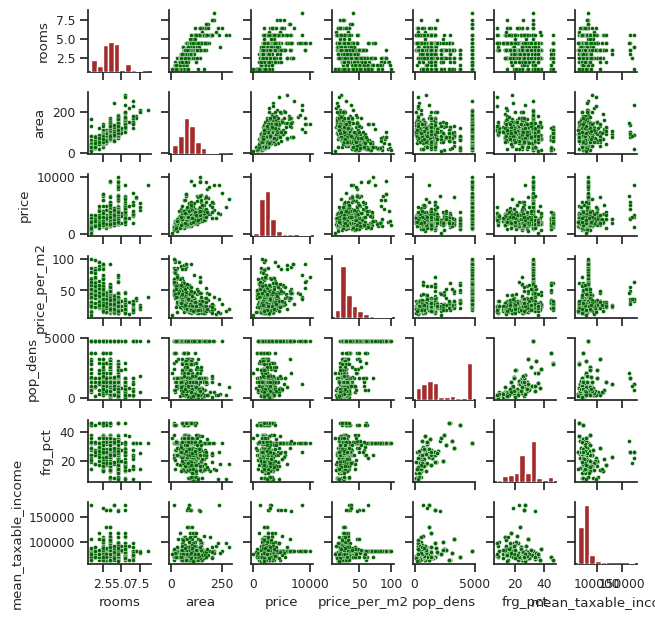

In [8]:
sns.set(style="ticks", font_scale=0.8)
g = sns.PairGrid(df[['rooms',
                     'area',
                     'price',
                     'price_per_m2',
                     'pop_dens',
                     'frg_pct',
                     'mean_taxable_income']], 
                 height=0.9, 
                 aspect=1)
g.map_upper(sns.scatterplot,color='darkgreen', s=8)
g.map_lower(sns.scatterplot, color='darkgreen', s=8)
g.map_diag(plt.hist, color='brown')

## Scatterplots and Pearson correlation of selected variables

### Scatterplot price versus area

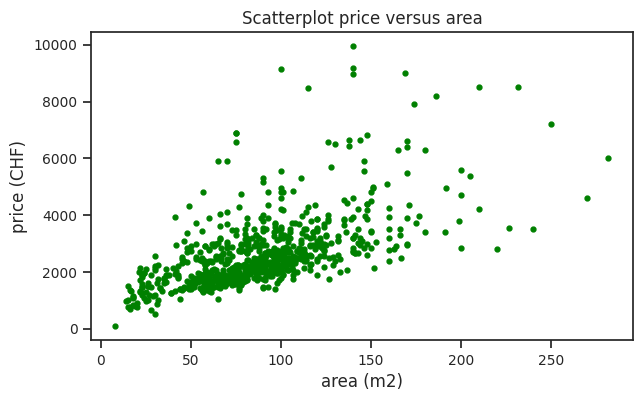

In [9]:
# Scatterplot
plt.figure(figsize=(7,4))
plt.plot(df['area'], 
         df['price'], 
         'o', 
         markersize=3.5,
         color="green")

# Add title and axes labels
plt.title('Scatterplot price versus area', fontsize=12)
plt.ylabel('price (CHF)', fontsize=12)
plt.xlabel('area (m2)', fontsize=12)

# Set fontsize of tick labels
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.show()

### Pearson correlation price versus area

In [10]:
# Perform Persons correlation
res = scipy.stats.pearsonr(df['area'], df['price'])

# Print result
print(f'Persons correlation coefficient (r): {res[0]:.4f}')
print(f'p-value: {res[1]:.4f}')

Persons correlation coefficient (r): 0.6120
p-value: 0.0000


### Scatterplot price_per_m2 versus area

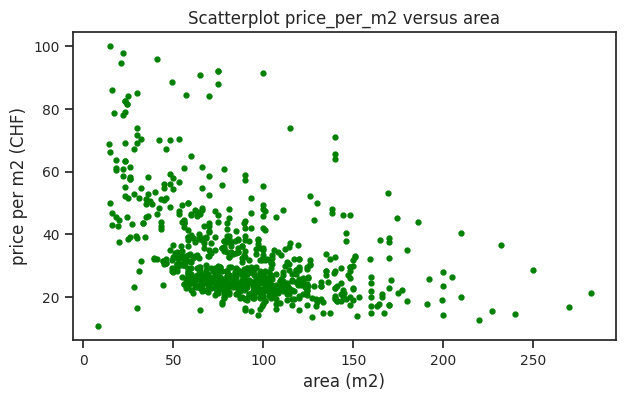

In [11]:
# Scatterplot
plt.figure(figsize=(7,4))
plt.plot(df['area'], 
         df['price_per_m2'], 
         'o', 
         markersize=3.5,
         color="green")

# Add title and axes labels
plt.title('Scatterplot price_per_m2 versus area', fontsize=12)
plt.ylabel('price per m2 (CHF)', fontsize=12)
plt.xlabel('area (m2)', fontsize=12)

# Set fontsize of tick labels
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.show()

### Pearson correlation price_per_m2 versus area

In [12]:
# Perform Persons correlation
res = scipy.stats.pearsonr(df['area'], df['price_per_m2'])

# Print result
print(f'Persons correlation coefficient (r): {res[0]:.4f}')
print(f'p-value: {res[1]:.4f}')

Persons correlation coefficient (r): -0.4564
p-value: 0.0000


### Log-transform price_per_m2 and area to make the relationship linear

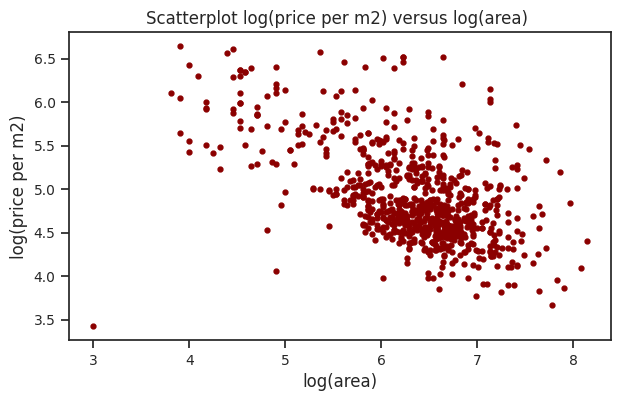

In [13]:
# Transform values of price_per_m2 to make it linear
df['log_price_per_m2'] = np.log2(df['price_per_m2'])
df['log_area'] = np.log2(df['area'])

# Scatterplot
plt.figure(figsize=(7,4))
plt.plot(df['log_area'], 
         df['log_price_per_m2'], 
         'o', 
         markersize=3.5,
         color="darkred")

# Add title and axes labels
plt.title('Scatterplot log(price per m2) versus log(area) ', fontsize=12)
plt.ylabel('log(price per m2)', fontsize=12)
plt.xlabel('log(area)', fontsize=12)

# Set fontsize of tick labels
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.show()

### Pearson correlation log(price_per_m2) versus log(area)

In [14]:
# Perform Pearson's correlation
res = scipy.stats.pearsonr(df['log_area'], df['log_price_per_m2'])

# Print result
print(f'Persons correlation coefficient (r): {res[0]:.4f}')
print(f'p-value: {res[1]:.4f}')

Persons correlation coefficient (r): -0.5556
p-value: 0.0000


## Correlation analysis based on car data

### Import car data

In [15]:
import pandas as pd

# Define columns for import
columns = ['Offer_Id',
          'Type',
          'Init_Regist',
          'Kilometer',
          'Price_Num',
          'PS_Num']

# Read the data and show header info
df_cars = pd.read_csv('autoscout24_data.csv', sep=";")[columns]

# Kilometer to numeric value
df_cars['Kilometer_Num'] = df_cars['Kilometer'].str.replace(' km', '').str.replace('\'', '').astype('int64')

# Remove original column 'Kilometer' 
df_cars = df_cars.drop(columns=['Kilometer'])

# Rename columns
df_cars = df_cars.rename(columns={'Price_Num':'Price', 'PS_Num':'PS', 'Kilometer_Num':'Kilometer'})
print('Number of rows and columns:', df_cars.shape)

# print header info
df_cars

Number of rows and columns: (3980, 6)


,Offer_Id,Type,Init_Regist,Price,PS,Kilometer
0,7324420,AUDI A5 Sportback 3.0 TDI quattro S-tronic (Li...,10.2014,22500,245,75000
1,7512768,MERCEDES-BENZ SLK 200 7G-Tronic (Cabriolet),6.2013,23749,184,46655
2,7512034,MERCEDES-BENZ C 350 Avantgarde 4Matic 7G-Troni...,6.2011,18500,306,138955
3,7512728,MERCEDES-BENZ A 45 AMG 4Matic Speedshift 7G-DC...,8.2015,36000,360,43000
4,7490242,AUDI A5 Sportback 2.0 TFSI Sport quattro S-tro...,9.2018,48500,252,43300
...,...,...,...,...,...,...
3975,7137137,FERRARI F360 Spider (Cabriolet),2.2002,58400,400,78000
3976,6758841,MERCEDES-BENZ SL 500 560 SL (Cabriolet),1.1987,15900,232,315000
3977,7461330,MERCEDES-BENZ CL 63 AMG 7G-Tronic (Coupé),8.2007,42000,525,85000
3978,7005403,BMW 328i Cabrio (Cabriolet),8.1995,9980,193,188920


### Correlation analysis based on car data


TASK 3: CORRELATION ANALYSIS - CAR DATA (AutoScout24)

PART c) EXPLORATORY ANALYSIS: PAIRED SCATTERPLOT MATRIX
--------------------------------------------------------------------------------


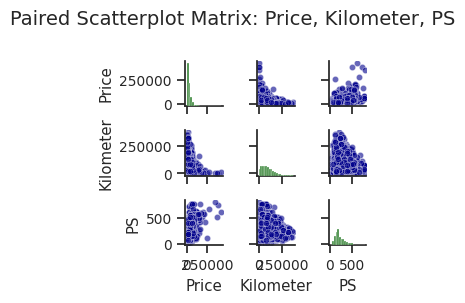

✓ Pairplot created successfully!
  - Diagonal: Histograms of each variable
  - Upper/Lower: Scatterplots showing relationships



In [18]:
print("\n" + "=" * 80)
print("TASK 3: CORRELATION ANALYSIS - CAR DATA (AutoScout24)")
print("=" * 80 + "\n")

print("PART c) EXPLORATORY ANALYSIS: PAIRED SCATTERPLOT MATRIX")
print("-" * 80)

# Create pairplot (scatterplot matrix)
sns.set(style="ticks", font_scale=0.9)
g = sns.pairplot(df_cars[['Price', 'Kilometer', 'PS']], 
                 height=1.0, 
                 aspect=1.0,
                 diag_kind='hist',
                 plot_kws={'s': 20, 'alpha': 0.6, 'color': 'darkblue'},
                 diag_kws={'color': 'darkgreen', 'bins': 20})

g.fig.suptitle('Paired Scatterplot Matrix: Price, Kilometer, PS', 
               fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("✓ Pairplot created successfully!")
print("  - Diagonal: Histograms of each variable")
print("  - Upper/Lower: Scatterplots showing relationships")
print()

### d CORRELATION 1 - Price vs. Kilometer

PART d) CORRELATION ANALYSIS WITH SIGNIFICANCE TESTS

1) CORRELATION: Price vs. Kilometer
--------------------------------------------------------------------------------
Pearson correlation coefficient (r): -0.4341
p-value: 1.3102e-182
Sample size (n): 3980
✓ Statistically SIGNIFICANT at α = 0.05
  → Strong NEGATIVE correlation: Higher mileage → Lower price



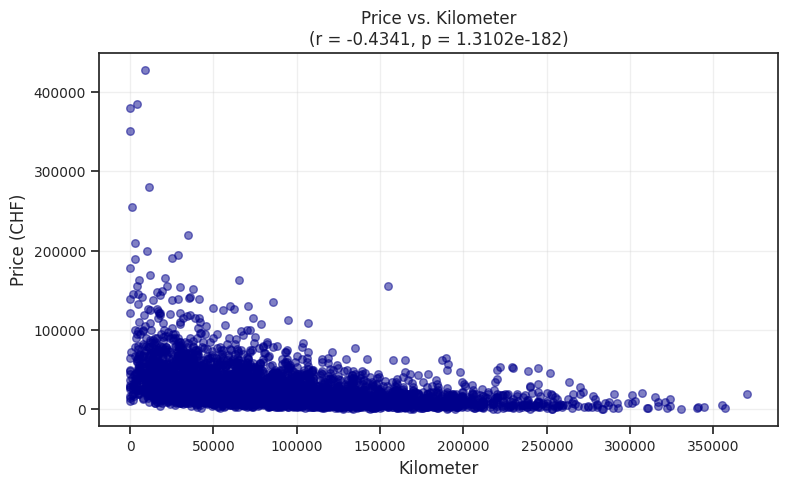

In [20]:
print("=" * 80)
print("PART d) CORRELATION ANALYSIS WITH SIGNIFICANCE TESTS")
print("=" * 80 + "\n")

print("1) CORRELATION: Price vs. Kilometer")
print("-" * 80)

# Perform Pearson correlation
res_price_km = scipy.stats.pearsonr(df_cars['Price'], df_cars['Kilometer'])

print(f"Pearson correlation coefficient (r): {res_price_km[0]:.4f}")
print(f"p-value: {res_price_km[1]:.4e}")
print(f"Sample size (n): {len(df_cars)}")

# Interpretation
alpha = 0.05
if res_price_km[1] < alpha:
    print(f"✓ Statistically SIGNIFICANT at α = 0.05")
    if res_price_km[0] < 0:
        print(f"  → Strong NEGATIVE correlation: Higher mileage → Lower price")
    else:
        print(f"  → Strong POSITIVE correlation: Higher mileage → Higher price")
else:
    print(f"✗ NOT statistically significant at α = 0.05")

print()

# Scatterplot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_cars['Kilometer'], df_cars['Price'], alpha=0.5, s=30, color='darkblue')
ax.set_xlabel('Kilometer', fontsize=12)
ax.set_ylabel('Price (CHF)', fontsize=12)
ax.set_title(f'Price vs. Kilometer\n(r = {res_price_km[0]:.4f}, p = {res_price_km[1]:.4e})', 
             fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()

### d CORRELATION 2 - Price vs. PS

2) CORRELATION: Price vs. PS (Horsepower)
--------------------------------------------------------------------------------
Pearson correlation coefficient (r): 0.6171
p-value: 0.0000e+00
Sample size (n): 3980
✓ Statistically SIGNIFICANT at α = 0.05
  → Strong POSITIVE correlation: More horsepower → Higher price



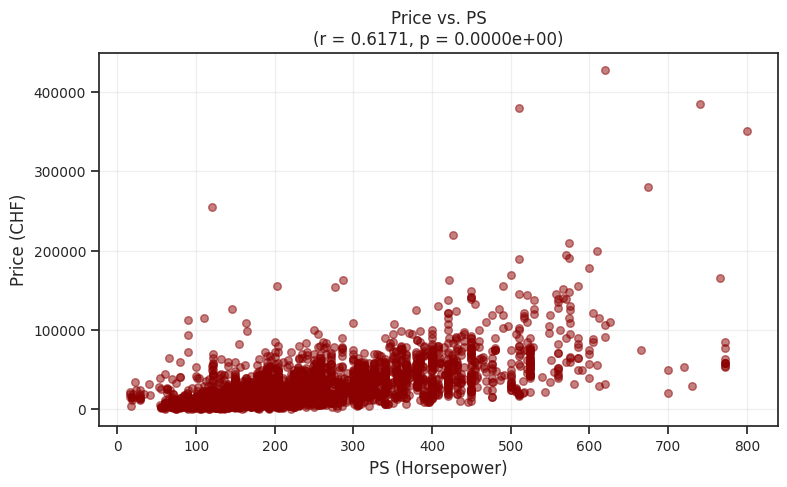

In [22]:
print("2) CORRELATION: Price vs. PS (Horsepower)")
print("-" * 80)

# Perform Pearson correlation
res_price_ps = scipy.stats.pearsonr(df_cars['Price'], df_cars['PS'])

print(f"Pearson correlation coefficient (r): {res_price_ps[0]:.4f}")
print(f"p-value: {res_price_ps[1]:.4e}")
print(f"Sample size (n): {len(df_cars)}")

# Interpretation
if res_price_ps[1] < alpha:
    print(f"✓ Statistically SIGNIFICANT at α = 0.05")
    if res_price_ps[0] < 0:
        print(f"  → Strong NEGATIVE correlation: More horsepower → Lower price")
    else:
        print(f"  → Strong POSITIVE correlation: More horsepower → Higher price")
else:
    print(f"✗ NOT statistically significant at α = 0.05")

print()

# Scatterplot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_cars['PS'], df_cars['Price'], alpha=0.5, s=30, color='darkred')
ax.set_xlabel('PS (Horsepower)', fontsize=12)
ax.set_ylabel('Price (CHF)', fontsize=12)
ax.set_title(f'Price vs. PS\n(r = {res_price_ps[0]:.4f}, p = {res_price_ps[1]:.4e})', 
             fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()

### d CORRELATION 3 - Kilometer vs. PS + SUMMARY TABLE

3) CORRELATION: Kilometer vs. PS (Horsepower)
--------------------------------------------------------------------------------
Pearson correlation coefficient (r): -0.1282
p-value: 4.7563e-16
Sample size (n): 3980
✓ Statistically SIGNIFICANT at α = 0.05
  → Strong NEGATIVE correlation: Higher mileage → Lower horsepower cars



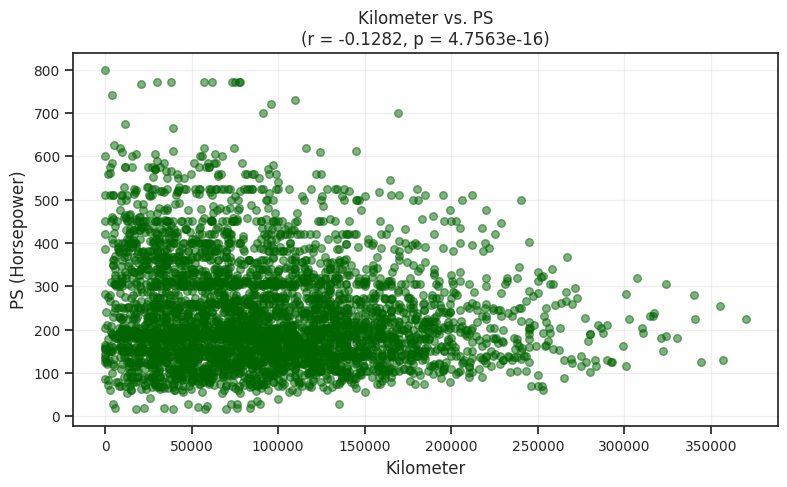

In [24]:
print("3) CORRELATION: Kilometer vs. PS (Horsepower)")
print("-" * 80)

# Perform Pearson correlation
res_km_ps = scipy.stats.pearsonr(df_cars['Kilometer'], df_cars['PS'])

print(f"Pearson correlation coefficient (r): {res_km_ps[0]:.4f}")
print(f"p-value: {res_km_ps[1]:.4e}")
print(f"Sample size (n): {len(df_cars)}")

# Interpretation
if res_km_ps[1] < alpha:
    print(f"✓ Statistically SIGNIFICANT at α = 0.05")
    if res_km_ps[0] < 0:
        print(f"  → Strong NEGATIVE correlation: Higher mileage → Lower horsepower cars")
    else:
        print(f"  → Strong POSITIVE correlation: Higher mileage → Higher horsepower cars")
else:
    print(f"✗ NOT statistically significant at α = 0.05")

print()

# Scatterplot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_cars['Kilometer'], df_cars['PS'], alpha=0.5, s=30, color='darkgreen')
ax.set_xlabel('Kilometer', fontsize=12)
ax.set_ylabel('PS (Horsepower)', fontsize=12)
ax.set_title(f'Kilometer vs. PS\n(r = {res_km_ps[0]:.4f}, p = {res_km_ps[1]:.4e})', 
             fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()

### SUMMARY TABLE

In [26]:
print("=" * 80)
print("SUMMARY TABLE: ALL CORRELATIONS")
print("=" * 80)

summary_data = {
    'Variable Pair': ['Price vs. Kilometer', 'Price vs. PS', 'Kilometer vs. PS'],
    'Pearson r': [f"{res_price_km[0]:.4f}", f"{res_price_ps[0]:.4f}", f"{res_km_ps[0]:.4f}"],
    'p-value': [f"{res_price_km[1]:.4e}", f"{res_price_ps[1]:.4e}", f"{res_km_ps[1]:.4e}"],
    'Significant (α=0.05)': [
        '✓ Yes' if res_price_km[1] < 0.05 else '✗ No',
        '✓ Yes' if res_price_ps[1] < 0.05 else '✗ No',
        '✓ Yes' if res_km_ps[1] < 0.05 else '✗ No'
    ]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print()
print("=" * 80)

SUMMARY TABLE: ALL CORRELATIONS
      Variable Pair Pearson r     p-value Significant (α=0.05)
Price vs. Kilometer   -0.4341 1.3102e-182                ✓ Yes
       Price vs. PS    0.6171  0.0000e+00                ✓ Yes
   Kilometer vs. PS   -0.1282  4.7563e-16                ✓ Yes



### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [27]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1030-azure
Datetime: 2025-10-30 12:06:21
Python Version: 3.11.13
-----------------------------------
